In [5]:
"""
run_p0.py  –  1D model quality illustration for the paper

Problem:  f(x) = |0.5 x^2 + x| = |x| * |1 + x/2|

Two decompositions:
  h(C(x)):  h = |·|,  C = 0.5x²+x   → prox-linear  (linearize C)
  s(R(x)):  s = y1*y2, R = (|x|, |1+x/2|)  → prox-convex (linearize s, keep R exact)

Produces: figures/p0/convexified_models.pdf
"""

import os
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

# ── Style ──────────────────────────────────────────────────────
matplotlib.rcParams.update({
    'font.family': 'serif',
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 13,
    'legend.fontsize': 10,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'lines.linewidth': 2.0,
    'figure.dpi': 150,
    'savefig.dpi': 600,
    'savefig.bbox': 'tight',
    'text.usetex': False,
})

C_ORIG = '#2ca02c'   # green  – original
C_HC   = '#d62728'   # red    – h(C) model
C_SR   = '#1f77b4'   # blue   – s(R) model

FIGDIR = 'figures/p0'
os.makedirs(FIGDIR, exist_ok=True)

In [6]:
# ═══════════════════════════════════════════════════════════════
# Functions
# ═══════════════════════════════════════════════════════════════

def f(x):
    """Original: f(x) = |0.5 x^2 + x|"""
    return np.abs(0.5 * x**2 + x)

# ── h(C(x)) decomposition ─────────────────────────────────────
def C_inner(x):
    return 0.5 * x**2 + x

def dC(x):
    return x + 1.0

def model_hC(x, x0):
    """Prox-linear model: |C(x0) + C'(x0)(x - x0)|"""
    return np.abs(C_inner(x0) + dC(x0) * (x - x0))

# ── s(R(x)) decomposition ─────────────────────────────────────
def R1(x):
    return np.abs(x)

def R2(x):
    return np.abs(1.0 + 0.5 * x)

def model_sR(x, x0):
    """Prox-convex model: R2(x0)|x| + R1(x0)|1+x/2| - R1(x0)R2(x0)"""
    r10 = R1(x0)
    r20 = R2(x0)
    return r20 * R1(x) + r10 * R2(x) - r10 * r20

Saved figures/p0/convexified_models


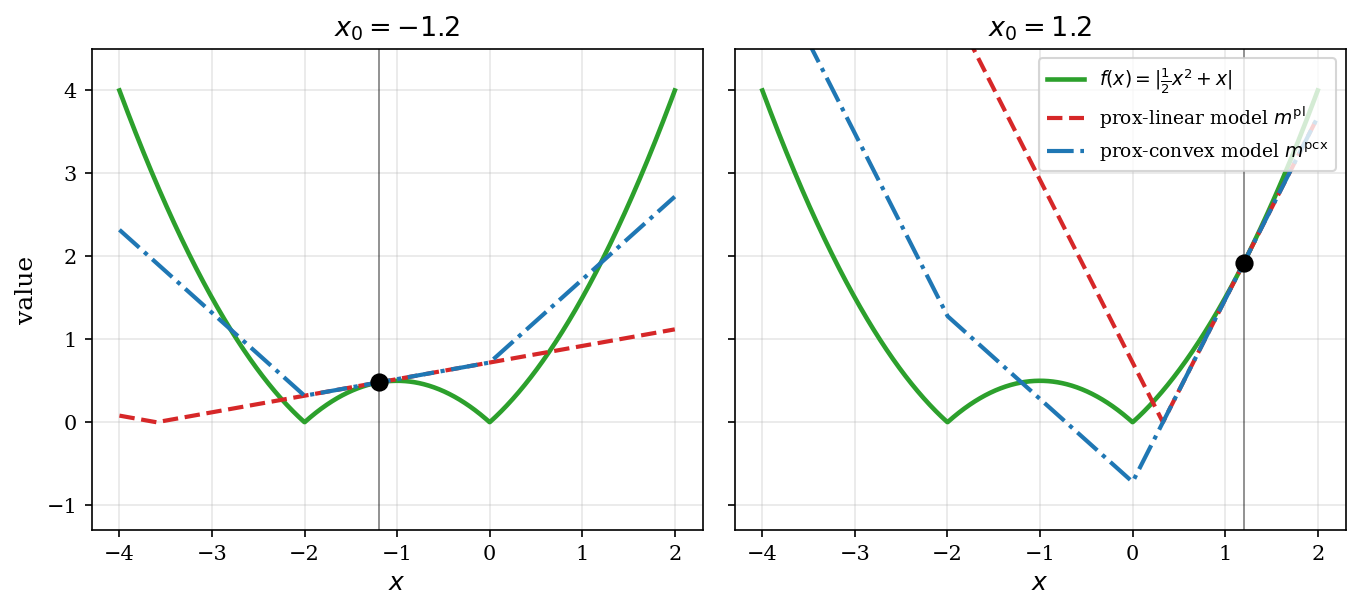

In [7]:
# ═══════════════════════════════════════════════════════════════
# Paper figure: multi-panel
# ═══════════════════════════════════════════════════════════════

x = np.linspace(-4.0, 2.0, 1200)
y_true = f(x)

x0_list = [-1.2, 1.2]

fig, axes = plt.subplots(1, len(x0_list), figsize=(9.2, 4.2), sharey=True)

for ax, x0 in zip(axes, x0_list):
    y_hC = model_hC(x, x0)
    y_sR = model_sR(x, x0)

    ax.plot(x, y_true, c=C_ORIG, linewidth=2.2, label=r'$f(x) = |\frac{1}{2}x^2 + x|$')
    ax.plot(x, y_hC, '--', c=C_HC, linewidth=2.0, label=r'prox-linear model $m^{\mathrm{pl}}$')
    ax.plot(x, y_sR, '-.', c=C_SR, linewidth=2.0, label=r'prox-convex model $m^{\mathrm{pcx}}$')
    ax.scatter([x0], [f(x0)], s=60, c='black', zorder=5)
    ax.axvline(x0, ls='-', c='black', linewidth=0.8, alpha=0.5)

    ax.set_title(rf'$x_0 = {x0}$')
    ax.set_xlabel(r'$x$')
    ax.set_ylim([-1.3, 4.5])
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel('value')
axes[-1].legend(fontsize=9, loc='upper right')
plt.tight_layout()
fig.savefig(f'{FIGDIR}/convexified_models.pdf')
fig.savefig(f'{FIGDIR}/convexified_models.png')
print(f'Saved {FIGDIR}/convexified_models')
plt.show()